## 5.2 합성곱 신경망 맛보기

### (1) 라이브러리 호출

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms # 전처리를 위해 사용하는 라이브러리
from torch.utils.data import Dataset, DataLoader

### (2) CPU 혹은 GPU 장치 확인

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"현재 사용하는 장치: {device}")

현재 사용하는 장치: cuda:0


### (3) fasion_mnist 데이터셋 받기

In [3]:
train_dataset = torchvision.datasets.FashionMNIST("./data", download=True,
                                                  transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST("./data", download=True,
                                               train=False, transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.5MB/s]


> `torchvision.datasets`
> * `torch.utils.data.Dataset`의 하위 클래스
> * CIFAR, COCO, MNIST, ImageNet 등
> * 주요 파라미터
>   * 첫번째 파라미터(`"./data"`)
>       * 데이터셋을 내려받을 경로 지정
>       * [코랩(Colab) 기준 참고]: "./data"처럼 지정하면 코랩 서버의 임시 가상 공간(로컬 폴더)에 저장됨.
>       * 런타임이 끊기면 데이터가 사라지지만, 별도의 드라이브 연동 없이 가장 빠르고 간편하게 실습할 수 있음 (영구 보관을 원하면 구글 드라이브 경로로 변경 가능).
>   * `download`: download를 True로 변경해주면 첫번째 파라미터의 위치에 해당 데이터셋이 있는지 확인한 후 내려받음
>   * `transform`: 이미지를 텐서(0~1)로 변환
>       * 일반 이미지의 픽셀 값(0\~255 정수)을 파이토치가 학습하기 좋은 0\~1 사이의 소수(실수) 형태로 바꾸고, 파이토치 전용 데이터 구조(Tensor)로 변환

### (4) fashion_mnisst 데이터를 데이터로더에 전달

In [4]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

> `torch.utils.data.DataLoader`
> * 원하는 크기의 배치 단위로 데이터 불러오기 및 shuffle 가능
> * 파라미터
>   * 첫번째 파라미터: 데이터를 불러올 데이터셋 지정
>   * `batch_size`: 데이터를 원하는 크기의 배치로 묶어줌

### (5) 분류에 사용될 클래스 정의

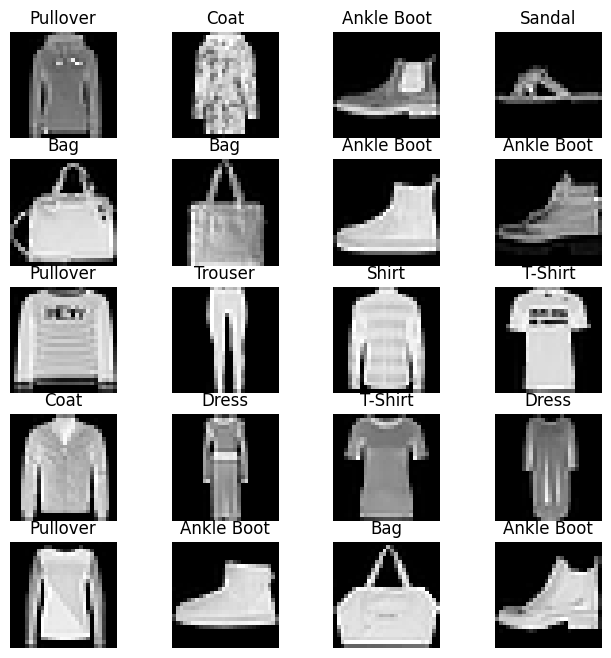

In [5]:
# 20개의 이미지를 레이블 정보와 함께 출력

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot"
}

fig = plt.figure(figsize=(8, 8))
columns = 4
rows = 5

for i in range(1, columns*rows+1):
  img_xy = np.random.randint(len(train_dataset)) # "0~train_dataset의 길이"의 값을 갖는 분포에서 랜덤한 숫자 한 개를 생성
  img = train_dataset[img_xy][0][0,:,:] #
  fig.add_subplot(rows, columns, i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis("off")
  plt.imshow(img, cmap="gray")
plt.show() # 20개의 이미지 데이터를 시각적으로 표현

#### `rand`, `randn`, `randint`의 차이와 파라미터

`np.random.randint(low, high=None, size=None)`
- 출력 분포: 지정한 범위 내의 정수 (Uniform Integers)

In [6]:
import numpy as np
np.random.randint(10) # 0~10의 임의의 숫자 출력

9

In [7]:
np.random.randint(1, 10) # 1~9의 임의의 숫자 출력

6

`np.random.rand(d0, d1, ...)`
- 출력 분포: 0과 1 사이의 균등 분포 (Uniform Distribution)
- 파라미터: 생성할 배열의 차원 크기 (d0, d1, ...)를 각각 개별 인자로 입력
- 특징: 최솟값 0, 최댓값 1 사이에서 균일한 확률로 난수를 추출

In [8]:
np.random.rand(8)
# 0과 1 사이의 균등 분포에서 추출한 난수로 크기가 (8,)인 1차원 배열(1차원 형태)로 출력

array([9.32768843e-01, 3.67257646e-04, 2.77338173e-01, 6.74094431e-02,
       9.66207760e-01, 8.67709441e-01, 5.04947315e-01, 7.82285273e-01])

In [9]:
np.random.rand(4,2)
# 0과 1 사이의 균등 분포에서 추출한 난수로 크기가 (4, 2)인 2차원 행렬로 출력

array([[0.28487579, 0.71415403],
       [0.55983146, 0.29963246],
       [0.60425424, 0.89823934],
       [0.00152734, 0.85234225]])

`.random.randn(d0, d1, ...)`
- 출력 분포: 평균이 0, 표준편차가 1인 정규분포 (Standard Normal Distribution)
- 파라미터: 생성할 배열의 차원 크기 (d0, d1, ...)를 각각 개별 인자로 입력
- 특징: 종 모양의 정규분포에서 가우시안 난수를 추출

In [10]:
np.random.randn(8)
# 평균이 0, 표준편차가 1인 정규분포 난수로 크기가 (8,)인 1차원 배열 생성

array([ 0.73034124, -0.35867719, -1.76959982, -0.76644938,  1.22110122,
        0.46283324,  0.18083273, -2.33867618])

In [11]:
np.random.randn(4,2)
# 평균이 0, 표준편차가 1인 정규분포 난수로 크기가 (4, 2)인 2차원 배열 생성

array([[ 0.39382626, -1.44887898],
       [ 0.24423975,  0.0029662 ],
       [-0.19291417, -0.51534701],
       [ 0.94026871, -0.64035907]])

#### `train_dataset[img_xy][0][0,:,:]`의 의미
- `train_dataset[img_xy]`: `img_xy` 번째 데이터에 접근
  - `[0]`: 이미지 데이터 → `[1]`은 레이블
- `[0,:,:]`: **채널 차원에서 0번째 채널의 전체 픽셀 데이터**를 가져옴
  - 파이토치는 이미지를 기본적으로 **`(채널, 세로, 가로)`** 형태로 다룸
  - 따라서 흑백 이미지도 채널이 1개이므로 `(1, 28, 28)` 형태로 저장됨
  - `[0,:,:]`를 적용하면 `(1, 28, 28)` → `(28, 28)`로 변환되어 **2차원 이미지 형태**가 됨
  - 이렇게 가져온 2차원 데이터를 `matplotlib`로 이미지로 출력할 수 있음

##### 배열

In [12]:
import numpy as np
examp = np.arange(0,100,3) #0부터 100전까지 3씩 건너뛰며
examp.resize(6,4) # 행렬 크기를 (6,4)로 조정
examp

array([[ 0,  3,  6,  9],
       [12, 15, 18, 21],
       [24, 27, 30, 33],
       [36, 39, 42, 45],
       [48, 51, 54, 57],
       [60, 63, 66, 69]])

In [13]:
examp[3] # 3행에 해당하는 값들

array([36, 39, 42, 45])

In [14]:
examp[3,3] # 3행의 3번째 열에 해당하는 값

np.int64(45)

In [15]:
examp[3][3] # 앞과 동일

np.int64(45)

##### `reshape` vs `resize`


1. `reshape`: 모양만 바꾸기 (안전제일)

* **특징:** 기존 배열의 데이터를 건드리지 않고, **모양(Shape)만 바꾼 새로운 배열을 반환** (원본 배열은 그대로 유지됨)
* **조건:** 바꾸려는 모양의 총 원소 개수(행 $\times$ 열)가 원래 배열의 총 원소 개수와 **반드시 완벽하게 일치**함 (다르면 에러)
* **사용 예시:**
  ```python
  a = np.arange(6)  # [0, 1, 2, 3, 4, 5] (원소 6개)
  b = a.reshape(2, 3)  # (2행 3열로 모양만 바꿈)

  ```

2. `resize`: 원본을 직접 수정하고 공간 맞춤

* **특징:** 새로운 배열을 반환하는 것이 아니라, **원본 배열 자체의 모양을 직접 바꿈(In-place)** ->  반환값은 항상 `None`
* **차이점:** 바꾸려는 모양의 총 원소 개수가 원래 배열의 개수와 **달라도 에러가 나지 않음**
  * 원소가 부족 -> 자리를 **0으로 채워 넣음**
  * 원소가 넘침 -> 뒤를 **잘라버림**


* **사용 예시:**
* `examp`는 `np.arange(0, 100, 3)`으로 만들어서 총 원소가 **34개**입니다.
* 하지만 `examp.resize(6, 4)`를 하면 6 $\times$ 4 = **24개**만 필요하므로, **뒤에 있는 10개의 데이터는 과감하게 잘려나가고** 딱 24개짜리 6행 4열 행렬로 변신하게 됩니다.

---
원본 데이터를 안전하게 유지하면서 모양만 바꾸고 싶다면 `reshape`를 쓰는 것이 훨씬 안전

### (6) 심층 신경망 모델 생성

In [16]:
class FashionDNN(nn.Module):
  def __init__(self):
    super(FashionDNN, self).__init__() # 부모의 초기화 함수 호출
    self.fc1 = nn.Linear(in_features=784, out_features=256) # -> Wx+b
    self.drop = nn.Dropout(0.25) # -> 25%를 드롭아웃
    self.fc2 = nn.Linear(in_features=256, out_features=128)
    self.fc3 = nn.Linear(in_features=128, out_features=10) # 0~9까지의 레이블이 있으니 out_features는 10

  def forward(self, input_data):
    out = input_data.view(-1,784) # 1차원으로 길쭉하게 펴줌
    out = F.relu(self.fc1(out))
    # 784개의 입력이 fc1을 지나며 256개의 출력(뉴런 값)으로 바뀜 + relu로 인해 음수는 0 값이 됨
    out = self.drop(out)
    # fc1이 만들어낸 256개의 결과물 중에서 25%를 무작위로 골라 0으로 훅 꺼버림.
    out = F.relu(self.fc2(out))
    # 25%가 0이 된 상태의 데이터가 다음 층인 fc2로 들어감
    out = self.fc3(out)
    return out

#### > PyTorch 순전파(Forward Pass)

> * forward() 실행 방식
>   * forward()를 직접 호출하지 않고 model(input_data) 형태로 모델을 호출
>   * PyTorch가 내부적으로 forward()를 실행함
> * 순전파(Forward Pass)
>   * 입력값 x를 모델에 넣어 예측값 y를 계산하는 전체 과정
>   * 가중치·편향 계산, 활성화 함수 적용 등의 과정을 거침
>   * H(x): 모델이 입력 x를 받아 예측값을 계산하는 함수
>     * 모델 구조와 활성화 함수에 따라 형태가 달라짐

#### `nn.xx` vs `F.xx`
> `nn.xx` → **레이어로 정의해서 사용**
> `F.xx` → **필요한 곳에서 함수로 직접 호출**

* **`nn.xx`**: Module(레이어) 형태

  * `__init__()`에서 **레이어를 정의**하고 `forward()`에서 사용
  * 파라미터(Weight, Bias)를 **자동으로 관리**
  * `nn.Sequential`에 넣을 수 있음
  * 예: `nn.Conv2d()`, `nn.ReLU()`

In [17]:
import torch
import torch.nn as nn

inputs = torch.randn(64,3,244,244)
conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1) # 합성곱층
outputs=conv(inputs)
layer=nn.Conv2d(1,1,3)

* **`F.xx`**: 함수 형태

  * `forward()`에서 **필요한 연산을 직접 호출**
  * 파라미터를 자동으로 관리하지 않음 → 필요한 경우 직접 전달
  * `nn.Sequential`에 넣을 수 없음
  * 예: `F.conv2d()`, `F.relu()`


In [18]:
import torch.nn.functional as F

inputs = torch.randn(64,3,244,244)
weight = torch.randn(64,3,3,3)
bias = torch.randn(64)
outputs = F.conv2d(inputs, weight, bias, padding=1)

### (7) 심층 신경망에서 필요한 파라미터 정의

In [19]:
learning_rate = 0.001
model = FashionDNN()
model.to(device)

criterion = nn.CrossEntropyLoss() # 분류 문제에서 사용하는 손실함수
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate) # 경사하강법으로 Adam 사용
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


### (8) 심층 신경망을 이용한 모델 학습

In [20]:
num_epochs = 5
count = 0

loss_list = []
iteration_list = []
accuracy_list = []
predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    # 모델이GPU에 있으니, 데이터도 GPU(device)로 보냄!!!
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    loss = criterion(outputs, labels)

    optimizer.zero_grad() # 그래디언트 초기화 (가중치 =/ 그래디언트)
    loss.backward()
    optimizer.step() # 가중치 업데이트
    count += 1 # 지금까지 몇 번째 배치를 처리했는지

    if not (count % 50): # 배치를  50번 처리할 때마다 실행됨
      total = 0
      correct = 0
      model.eval() # 평가모드로 전환(dropout 등 비활성화)
      with torch.no_grad(): # 평가할 때는 기울기 계산 X -> 메모리 절약 및 속도 향상
        for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          labels_list.append(labels)
          outputs = model(images)
          predictions = torch.max(outputs,1)[1]
          # torch.max(outputs, dim=1)[1]
          # dim = 1 -> 행 방향을 기준으로 최댓값을 찾아fk
          # [1] -> [0]에는 가장 큰 값 자체가 들어 있고, [1]에 가장 큰 값이 들어있떤 위치(여기선 예측한 클래스 번호)가 들어있음
          predictions_list.append(predictions)
          correct+=(predictions==labels).sum().item()
          # predictions와 labels는 둘 다 텐서 -> ==을 하면 인텍스 별로 일일이 비교함 -> 결과 예시: [True, False, False]
          # sum()을 하면 배열의 합을 구해 몇 개나 맞췄는지 그 총합이 텐서 형태로 나옴
          # .item()을 사용하면 텐서 객체 안의 파이썬 숫자만 쏙 빼냄 -> 메모리 누수 방지
          total += len(labels)


      accuracy = correct * 100/total
      loss_list.append(loss.item()) # .data보다는 .item() 사용을 추천
      iteration_list.append(count)
      accuracy_list.append(accuracy)

      model.train() # 학습 모드로 전환

    if not (count%500): # 배치를  500번 처리할 때마다 실행됨
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.item(), accuracy))

Iteration: 500, Loss: 0.5529937148094177, Accuracy: 84.11%
Iteration: 1000, Loss: 0.4586489796638489, Accuracy: 85.03%
Iteration: 1500, Loss: 0.40090546011924744, Accuracy: 85.18%
Iteration: 2000, Loss: 0.4351324737071991, Accuracy: 85.92%
Iteration: 2500, Loss: 0.31410378217697144, Accuracy: 87.13%
Iteration: 3000, Loss: 0.26499637961387634, Accuracy: 87.33%


#### 정확도(Accuracy) 계산과 주의점

* **정확도(Accuracy)** = $\frac{\text{맞춘 개수}}{\text{전체 개수}} \times 100$
* **오인식률(Error Rate)** = $\frac{\text{틀린 개수}}{\text{전체 개수}} \times 100$

  * = $1 - \text{Accuracy}$

##### 불균형 데이터(Imbalanced Data)

* 클래스별 데이터의 수가 크게 차이 나는 경우, **정확도만으로 모델 성능을 판단하면 안 됨**
* 예: 정상 99명, 환자 1명인 데이터에서 모두 정상으로 예측

  * 정확도 = **99%** but 환자는 한 명도 찾지 못함
 => 따라서 **데이터가 한쪽 클래스에 치우쳐 있는지 확인**해야 함.

### (9) 합성곱 네트워크 생성

In [21]:
class FashionCNN(nn.Module):
    def __init__(self):
      super(FashionCNN, self).__init__()
      self.layer1 = nn.Sequential(
          nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
          # 한개의 채널(흑백)에서 32개의 필터를 가지고 32개의 특성맵을 만들어 32개의 채널을 만듦
          nn.BatchNorm2d(32), # 특성맵에 정규화를 먹임
          nn.ReLU(), # 특성맵에서 음수인 것은 0으로 싹 바꿈
          nn.MaxPool2d(kernel_size=2, stride=2) # 특성맵을 2x2의 필터에 넣어 최댓값만 골아 작아진 새로운 특성맵을 만듦
      )
      self.layer2 = nn.Sequential(
          nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
          nn.BatchNorm2d(64),
          nn.ReLU(),
          nn.MaxPool2d(2)
      )
      self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
      self.drop = nn.Dropout2d(0.25)
      self.fc2 = nn.Linear(in_features=600, out_features=120)
      self.fc3 = nn.Linear(in_features=120, out_features=10)
    def forward(self, x):
      out = self.layer1(x)
      out = self.layer2(out)
      out = out.view(out.size(0), -1) # 완전연결층으로 넘어가기 전 1차원으로 변
      out = self.fc1(out)
      out = self.drop(out)
      out = self.fc2(out)
      out = self.fc3(out)
      return out

### (10) 합성곱 네트워크를 위한 파라미터 정의

In [23]:
learning_rate = 0.001
model=FashionCNN()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


### (11) 모델 학습 및 성능 평가

In [28]:
num_epochs=15
count=0
loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    outputs=model(images)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count +=1

    if not (count%50):
      total=0
      correct=0
      model.eval()
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        outputs=model(images)
        predictions=torch.max(outputs,1)[1]
        predictions_list.append(predictions)
        correct+=(predictions==labels).sum().item()
        total += len(labels)

      accuracy = correct*100/total
      loss_list.append(loss.item())
      iteration_list.append(count)
      accuracy_list.append(accuracy)
      model.train()

    if not (count%500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.item(), accuracy))


Iteration: 500, Loss: 0.812172532081604, Accuracy: 75.76%
Iteration: 1000, Loss: 0.8217887282371521, Accuracy: 74.02%
Iteration: 1500, Loss: 0.6288893222808838, Accuracy: 74.55%
Iteration: 2000, Loss: 0.8756975531578064, Accuracy: 76.05%
Iteration: 2500, Loss: 0.6273638010025024, Accuracy: 77.05%
Iteration: 3000, Loss: 0.6224790215492249, Accuracy: 77.68%
Iteration: 3500, Loss: 0.7176626324653625, Accuracy: 79.32%
Iteration: 4000, Loss: 0.5814749002456665, Accuracy: 79.74%
Iteration: 4500, Loss: 0.5370917320251465, Accuracy: 78.42%
Iteration: 5000, Loss: 0.5139220952987671, Accuracy: 82.08%
Iteration: 5500, Loss: 0.519744336605072, Accuracy: 80.6%
Iteration: 6000, Loss: 0.5442141890525818, Accuracy: 81.92%
Iteration: 6500, Loss: 0.5418336391448975, Accuracy: 81.89%
Iteration: 7000, Loss: 0.4371131956577301, Accuracy: 83.8%
Iteration: 7500, Loss: 0.4338195025920868, Accuracy: 81.69%
Iteration: 8000, Loss: 0.461762011051178, Accuracy: 84.11%
Iteration: 8500, Loss: 0.4388878643512726, Acc